<b>Библиотека sklearn и классификация с помощью KNN</b></h1>

## Часть 1. Анализ и предобработка данных

* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 39.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 83.6MB/s]


**Задание 1.1.** Импортируем библиотеки pandas, matplotlib, seaborn



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics, model_selection

**Задание 1.2.** Загружаем датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделаю значения колонки `S.No` наименованиями строк:

In [ ]:
test_data = pd.read_csv("game_of_thrones_test.csv",index_col='S.No')
train_data = pd.read_csv("game_of_thrones_train.csv",index_col='S.No')

Посмотрим, какие типы данных представлены в датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)
- для удобства восприятия транспонируем таблицу

In [ ]:
train_data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [ ]:
test_data.describe(include='object').T

,count,unique,top,freq
name,389,389,Tytos Lannister,1
title,221,109,Ser,78
culture,189,48,Northmen,30
mother,3,3,Dyanna Dayne,1
father,4,4,Maekar I Targaryen,1
heir,2,2,Duncan Targaryen,1
house,343,137,House Targaryen,22
spouse,76,75,Tyrion Lannister,2


Теперь давайте посмотрим на столбцы с числовыми типами данных. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение.


In [ ]:
train_data.describe(include = ['float64','int64']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа.

**Задание 1.3.** Предобработка (очистка) данных.

Все пропуски в данных (missing values) уже закодированы как NaN. Проанализируем, в каких колонках и как часто встречаются NaN значения. Далее надо будет принять решение, как их обрабатывать.

In [ ]:
train_data.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [ ]:
test_data.isna().sum()

,0
name,0
title,168
male,0
culture,200
dateOfBirth,235
mother,386
father,385
heir,387
house,46
spouse,313


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN. Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



В наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ.

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Построим гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

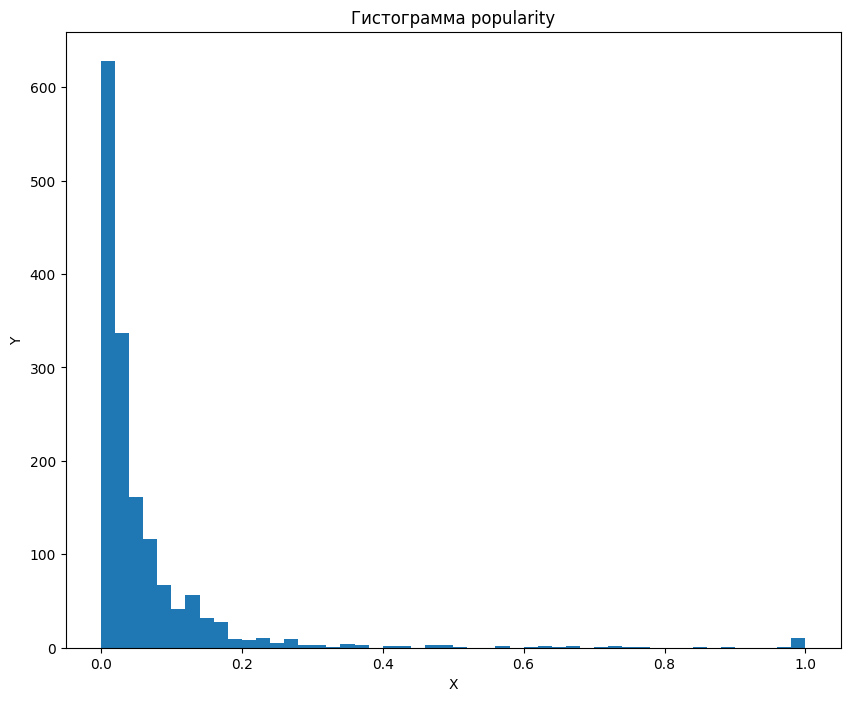

In [ ]:
plt.figure(figsize=(10,8))
plt.title("Гистограмма popularity")
plt.hist(train_data['popularity'],bins=50)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для нектоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

Для `popularity` можно использовать свой способ шкалирования признаков с несимметричным распределением.


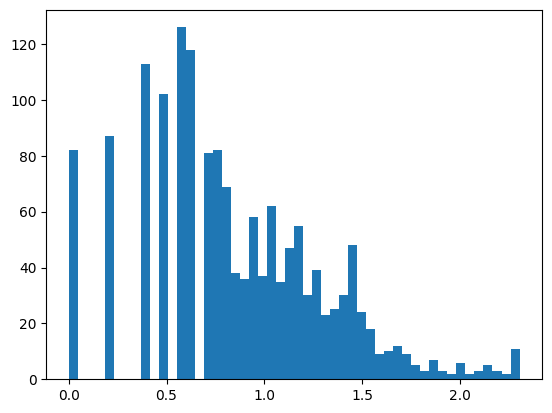

In [ ]:
M=200
train_data['popularity']=np.log10(train_data['popularity']*M+1)
plt.hist(train_data['popularity'],bins=50)
plt.show()


В качестве альтернативного подхода можно попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае мы преобразуем числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь обработаем **признак numDeadRelations**.
Посмотрим на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создаем признак `boolDeadRelations`. Упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

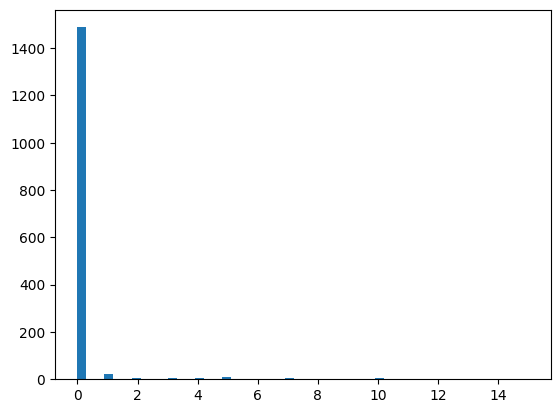

In [ ]:
plt.hist(train_data['numDeadRelations'],bins=50)
plt.show()

In [ ]:
train_data['boolDeadRelations']=[0 if x==0 else 1 for x in train_data['numDeadRelations']]
train_data[['boolDeadRelations','numDeadRelations']].head(8)

,boolDeadRelations,numDeadRelations
S.No,,
1,1,11
2,1,1
3,0,0
4,0,0
5,0,0
6,1,5
7,0,0
8,1,5


In [ ]:
train_data.drop(columns='numDeadRelations',inplace=True)
train_data.columns.tolist()

['name',
 'title',
 'male',
 'culture',
 'dateOfBirth',
 'mother',
 'father',
 'heir',
 'house',
 'spouse',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'age',
 'popularity',
 'isAlive',
 'boolDeadRelations']

Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [ ]:
train_data['age_value'] = [0 if np.isnan(x) else x for x in train_data['age']]
train_data['age_no_data'] = [1 if np.isnan(x) else 0 for x in train_data['age']]
train_data[['age','age_value','age_no_data']].head(8)

,age,age_value,age_no_data
S.No,,,
1,NaN,0.0,1
2,97.0,97.0,0
3,NaN,0.0,1
4,23.0,23.0,0
5,29.0,29.0,0
6,NaN,0.0,1
7,26.0,26.0,0
8,NaN,0.0,1


In [ ]:
train_data.drop(columns='age',inplace=True)
train_data.columns.tolist()

['name',
 'title',
 'male',
 'culture',
 'dateOfBirth',
 'mother',
 'father',
 'heir',
 'house',
 'spouse',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'popularity',
 'isAlive',
 'boolDeadRelations',
 'age_value',
 'age_no_data']

In [ ]:
train_data['dateOfBirth_value'] = [0 if np.isnan(x) else x for x in train_data['dateOfBirth']]
train_data['dateOfBirth_no_data'] = [1 if np.isnan(x) else 0 for x in train_data['dateOfBirth']]
train_data[['dateOfBirth','dateOfBirth_value','dateOfBirth_no_data','age_no_data']].head(8)

,dateOfBirth,dateOfBirth_value,dateOfBirth_no_data,age_no_data
S.No,,,,
1,NaN,0.0,1,1
2,208.0,208.0,0,0
3,NaN,0.0,1,1
4,82.0,82.0,0,0
5,276.0,276.0,0,0
6,NaN,0.0,1,1
7,183.0,183.0,0,0
8,NaN,0.0,1,1


In [ ]:
train_data.drop(columns=['dateOfBirth','dateOfBirth_no_data'],inplace=True)
train_data.columns.tolist()

['name',
 'title',
 'male',
 'culture',
 'mother',
 'father',
 'heir',
 'house',
 'spouse',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'popularity',
 'isAlive',
 'boolDeadRelations',
 'age_value',
 'age_no_data',
 'dateOfBirth_value']

Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

У одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [ ]:
train_data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [ ]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря).

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

В словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [ ]:
d_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      d_inverted.update({v:k})

train_data['culture_grouped'] = train_data['culture'].str.lower().map(d_inverted)
train_data[['culture','culture_grouped']].head(12)

,culture,culture_grouped
S.No,,
1,NaN,NaN
2,Rivermen,the Isles and Rivers
3,NaN,NaN
4,NaN,NaN
5,Dornish,Dorne
6,NaN,NaN
7,Valyrian,Old Nations
8,NaN,NaN
9,NaN,NaN


Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [ ]:
train_data['culture_grouped']=train_data['culture_grouped'].fillna('culture_no_data')
train_data[['culture','culture_grouped']].head(12)

,culture,culture_grouped
S.No,,
1,NaN,culture_no_data
2,Rivermen,the Isles and Rivers
3,NaN,culture_no_data
4,NaN,culture_no_data
5,Dornish,Dorne
6,NaN,culture_no_data
7,Valyrian,Old Nations
8,NaN,culture_no_data
9,NaN,culture_no_data


In [ ]:
train_data.drop(columns='culture',inplace=True)
train_data.columns.tolist()

['name',
 'title',
 'male',
 'mother',
 'father',
 'heir',
 'house',
 'spouse',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'popularity',
 'isAlive',
 'boolDeadRelations',
 'age_value',
 'age_no_data',
 'dateOfBirth_value',
 'culture_grouped']

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [ ]:
train_data.nunique()

,0
name,1557
title,195
male,2
mother,16
father,19
heir,20
house,315
spouse,186
book1,2
book2,2


In [ ]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
numerical_columns=['male','dateOfBirth_value','book1','book2','book3','book4','book5','isAliveMother','isAliveFather',
                   'isAliveHeir','isAliveSpouse','isMarried','isNoble','age_value','age_no_data','boolDeadRelations','popularity']
train_data.describe(include = ['float64','int64']).T[['count', 'min', 'max']].assign(N_unique_values = train_data.nunique())


,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2
isAliveSpouse,200.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [ ]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

# data.groupby('НАЗВАНИЕ ПРИЗНАКА', dropna = False)['isAlive'].mean()
# pd.pivot_table(data = data, values = 'isAlive', index = 'НАЗВАНИЕ ПРИЗНАКА', aggfunc=['mean', 'count'], dropna=False)

**Задание 1.7.** Проанализируем признаки.

In [ ]:
#Делаем One-Hot преобразование для признака culture_grouped. Вместо одного признака создадим 12.
LN=['Old Nations','the North','the Iron Islands','the Mountain and the Vale','the Isles and Rivers','the Rock',
    'the Stormlands','the Reach','Dorne','Essos Nations','Other Nations','culture_no_data']

for XI in LN:
    train_data[XI] = [1 if x == XI else 0 for x in train_data['culture_grouped']]

In [ ]:
train_data.columns.tolist() # Убедились что созданы новые признаки

['name',
 'title',
 'male',
 'mother',
 'father',
 'heir',
 'house',
 'spouse',
 'book1',
 'book2',
 'book3',
 'book4',
 'book5',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse',
 'isMarried',
 'isNoble',
 'popularity',
 'isAlive',
 'boolDeadRelations',
 'age_value',
 'age_no_data',
 'dateOfBirth_value',
 'culture_grouped',
 'Old Nations',
 'the North',
 'the Iron Islands',
 'the Mountain and the Vale',
 'the Isles and Rivers',
 'the Rock',
 'the Stormlands',
 'the Reach',
 'Dorne',
 'Essos Nations',
 'Other Nations',
 'culture_no_data']

In [ ]:
train_data.drop(columns='culture_grouped',inplace=True) #Удаляем признак 'culture_grouped'

**Задание 1.8.** Проанализируем влияние признаков на целевую переменную.

In [ ]:
train_data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [ ]:
# Создадим список признаков, которые оцифрованы.
# В этот список не вносим признаки'isAliveMother','isAliveFather','isAliveHeir','isAliveSpouse' так как в них очень мало данных
LL=['male','book1',
    'book2','book3','book4','book5','isMarried','isNoble','popularity',
    'boolDeadRelations','age_value','age_no_data','dateOfBirth_value',
    'Old Nations','the North','the Iron Islands',
    'the Mountain and the Vale','the Isles and Rivers','the Rock',
    'the Stormlands','the Reach','Dorne','Essos Nations','Other Nations',
    'culture_no_data']
# Посмотрим на корелляцию этих признаков. Выведем те пары, где корелляция
#  меньше -0.8 или больше 0.8
for xx in LL:
    for yy in LL:
         if (train_data[xx].corr(train_data[yy]) > 0.8) or (train_data[xx].corr(train_data[yy]) < -0.8):
             print(xx+'  '+yy,'  KOR=',train_data[xx].corr(train_data[yy]))

male  male   KOR= 1.0
book1  book1   KOR= 1.0
book2  book2   KOR= 1.0
book3  book3   KOR= 0.9999999999999999
book4  book4   KOR= 1.0
book5  book5   KOR= 0.9999999999999999
isMarried  isMarried   KOR= 0.9999999999999999
isNoble  isNoble   KOR= 1.0
popularity  popularity   KOR= 1.0
boolDeadRelations  boolDeadRelations   KOR= 1.0
age_value  age_value   KOR= 1.0
age_no_data  age_no_data   KOR= 1.0
age_no_data  dateOfBirth_value   KOR= -0.9644649811269268
dateOfBirth_value  age_no_data   KOR= -0.9644649811269269
dateOfBirth_value  dateOfBirth_value   KOR= 1.0
Old Nations  Old Nations   KOR= 1.0
the North  the North   KOR= 1.0
the Iron Islands  the Iron Islands   KOR= 0.9999999999999999
the Mountain and the Vale  the Mountain and the Vale   KOR= 1.0
the Isles and Rivers  the Isles and Rivers   KOR= 1.0
the Rock  the Rock   KOR= 1.0
the Stormlands  the Stormlands   KOR= 0.9999999999999999
the Reach  the Reach   KOR= 1.0
Dorne  Dorne   KOR= 1.0
Essos Nations  Essos Nations   KOR= 1.0
Other Nat

Видно, что кроме XX, кореллируют также и age_no_data-dateOfBirth_value. тем не менее , оставим эти признаки в модели. Как покажет дальнейшее обучение-
с этими признаками результат лучше.

In [ ]:
#Проверим корелляцию выбранных признаков на целевую переменную
for xx in LL:
  if (train_data[xx].corr(train_data['isAlive']) > 0.1) or (train_data[xx].corr(train_data['isAlive']) < -0.1):
             print(xx,'  KOR=',train_data[xx].corr(train_data['isAlive']))

male   KOR= -0.14829038351699395
book1   KOR= -0.11246821311184807
book4   KOR= 0.28401404157958926
popularity   KOR= -0.2400095044072333
boolDeadRelations   KOR= -0.17817685832813163
age_value   KOR= -0.18193838561919
age_no_data   KOR= 0.113628884569153
Old Nations   KOR= -0.17340945402056482


Видим, что корелляция признаков и целевой переменной есть у ряда выбранных признаков

**Задание 1.9.** Создадим переменные `X`, которая будет хранить только значения признаков, которые отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
x_tr = train_data[LL].copy()
y_tr = train_data[['isAlive']].copy()

**Задание 1.10.** Разделим датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
X_train,X_test,y_train,y_test=model_selection.train_test_split(x_tr, y_tr,test_size=0.1,random_state=40)

## Часть 2. Обучение моделей

В данной части, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**

Выберем и поработаем с моделью `LogisticRegression`.

Импортируем остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуемся официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html).

**Задание 2.2.** Обучим модель и сделаем предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
model = linear_model.LogisticRegression(max_iter=1000)
model.fit(X_train, y_train['isAlive'])
y_pred = model.predict(X_test)




## Часть 3. Оцените качество моделей

Познакомимся с метриками задачи классификации из sklearn. Оценим все модели и выберем лучшую по метрике качества Accuracy.

С метриками классификации мы можем ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = metrics.accuracy_score(y_test['isAlive'], y_pred) #Сравнили предсказанный столбец с целевым тестовым
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.83


Будем считать, что выбранные признаки нас устраивают.

### Тестовый датасет

В самом начале мы скачивали тестовый датасет. Загрузим его в Pandas DataFrame при помощи функции read_csv

Ниже приводится код для обработки и выбора признаков, который был выполнен выше для обучающих данных. Теперь это же выполняем для тестовых данных.

In [ ]:
M=200
test_data['popularity']=np.log10(test_data['popularity']*M+1)
test_data['boolDeadRelations']=[0 if x==0 else 1 for x in test_data['numDeadRelations']]
test_data.drop(columns='numDeadRelations',inplace=True) #Удаляем признак numDeadRelations

# В признаке age есть два выброса - отрицательные по значению и меньше -200000.
# Поэтому там где age<-200000 в age_no_data пишем 1, а в age_value 0
test_data['age_no_data'] = [1 if (np.isnan(x) or (x<-200000.)) else 0 for x in test_data['age']]
test_data['age_value'] = [0 if (np.isnan(x) or (x<-200000.)) else x for x in test_data['age']]
test_data.drop(columns='age',inplace=True) #Удаляем признак age

# В признаке dateOfBirth есть два выброса - положительные по значению и больше 200000.
# Поэтому там где dateOfBirth>200000 в dateOfBirth_no_data пишем 1, а в dateOfBirth_value 0
test_data['dateOfBirth_no_data'] = [1 if (np.isnan(x) or (x>200000.)) else 0 for x in test_data['dateOfBirth']]
test_data['dateOfBirth_value'] = [0 if (np.isnan(x) or (x>200000.)) else x for x in test_data['dateOfBirth']]
test_data.drop(columns=['dateOfBirth','dateOfBirth_no_data'],inplace=True) #Удаляем признаки 'dateOfBirth','dateOfBirth_no_data'

test_data['culture_grouped'] = test_data['culture'].str.lower().map(d_inverted)
test_data['culture_grouped']=test_data['culture_grouped'].fillna('culture_no_data')
test_data.drop(columns='culture',inplace=True) #Удаляем признак
#Делаем One-Hot преобразование для признака culture_grouped. Вместо одного признака создадим 12.
LN=['Old Nations','the North','the Iron Islands','the Mountain and the Vale','the Isles and Rivers','the Rock',
    'the Stormlands','the Reach','Dorne','Essos Nations','Other Nations','culture_no_data']
for XI in LN:
    test_data[XI] = [1 if x == XI else 0 for x in test_data['culture_grouped']]

test_data.drop(columns='culture_grouped',inplace=True) #Удаляем признак 'culture_grouped'

# Создадим список признаков, которые оцифрованы.
# В этот список не вносим признаки'isAliveMother','isAliveFather','isAliveHeir','isAliveSpouse' так как в них очень мало данных
LL=['male','book1',
    'book2','book3','book4','book5','isMarried','isNoble','popularity',
    'boolDeadRelations','age_value','age_no_data','dateOfBirth_value',
    'Old Nations','the North','the Iron Islands',
    'the Mountain and the Vale','the Isles and Rivers','the Rock',
    'the Stormlands','the Reach','Dorne','Essos Nations','Other Nations',
    'culture_no_data']

In [ ]:
# Предсказываем целевую переменную при помощи полученной выше модели, по тестовым данным
y_pred_test = model.predict(test_data[LL])
# Это наша цель!

Преобразуем признаки в тестовом датасете по тому же пайплайну, как обучающие данные. Применим нашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

### Файл `submission.csv`

Нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.6MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No') # Прочитали данные из файла

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission['isAlive']=y_pred_test # Записали предсказанную целевую переменную в дата фрейм
submission.to_csv("/content/new_submission.csv", index=False) # Сохранили файл